# Programa de entrenamiento del modelo
En dicho programa, se realiza el entrenamiento del modelo, con el centro de datos

### Realizado por:

In [2]:
## Librerías a utilizar:

#pandas: Para la carga, manipulación y análisis de datos estructurados (como nuestro dataset CSV consolidado).
import pandas as pd

#spacy: Para el procesamiento avanzado de lenguaje natural (NLP). Es vital para tareas pesadas como tokenización, lematización, eliminación de "stop words" y comprensión profunda de los mensajes.
import spacy

#re: Para trabajar con expresiones regulares. Fundamental en la etapa de preprocesamiento para limpiar el texto crudo.
import re

#pickle: Para serializar y guardar la jerarquía de objetos de Python. Se utilizará para exportar el modelo ya entrenado y el vectorizador a archivos físicos, permitiendo cargarlos posteriormente en el backend para realizar inferencias en tiempo real.
import pickle

#os: Para interactuar con el sistema operativo, permitiendo la creación de directorios y la gestión dinámica de rutas de archivos de forma segura y multiplataforma.
import os

#numpy: Para operaciones matemáticas de alto rendimiento y manejo de arreglos multidimensionales (arrays), base fundamental sobre la que operan otras librerías como scikit-learn.
import numpy as np

#matplotlib.pyplot: Para la creación de gráficos estáticos. Nos permitirá visualizar la distribución de nuestros datos, el equilibrio de clases o el rendimiento general del modelo.
import matplotlib.pyplot as plt

#seaborn: Construida sobre matplotlib, proporciona una interfaz de alto nivel para dibujar gráficos estadísticos más estéticos e informativos.
import seaborn as sns

#TruncatedSVD: De scikit-learn, se utiliza para la reducción de dimensionalidad espacial (LSA).
from sklearn.decomposition import TruncatedSVD

#train_test_split: Función esencial para dividir de forma aleatoria nuestro conjunto de datos en subconjuntos de entrenamiento (train) y prueba (test), garantizando una evaluación objetiva y evitando el sobreajuste (overfitting).
from sklearn.model_selection import train_test_split

#TfidfVectorizer: Transforma el texto crudo en una matriz de características numéricas utilizando el método TF-IDF (Frecuencia de Término - Frecuencia Inversa de Documento). Esto le da mayor peso matemático a las palabras que son verdaderamente relevantes y distintivas para la clasificación.
from sklearn.feature_extraction.text import TfidfVectorizer

#SVC (Support Vector Classification): El algoritmo principal de Machine Learning que emplearemos. Las Máquinas de Vectores de Soporte son altamente efectivas en espacios de alta dimensionalidad, lo que las hace ideales para encontrar el hiperplano óptimo que separa diferentes categorías de texto.
from sklearn.svm import SVC

#Métricas de scikit-learn para evaluar rigurosamente el modelo:
#accuracy_score: Para obtener el porcentaje total de predicciones correctas.
#classification_report: Para un desglose detallado que incluye la precisión (precision), sensibilidad (recall) y f1-score por cada clase.
#confusion_matrix: Para tabular las predicciones contra la realidad (Verdaderos Positivos, Falsos Positivos, Verdaderos Negativos, Falsos Negativos).
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

#hstack: De SciPy, permite apilar matrices dispersas de forma horizontal. Es la herramienta adecuada si en el futuro necesitamos combinar la matriz de texto generada por TF-IDF con otras características numéricas extraídas manualmente (como la longitud del mensaje o conteo de mayúsculas) antes de pasarlas al modelo.
from scipy.sparse import hstack

In [3]:
#Cargando el modelo de lenguaje de Spacy para español
print("1. Cargando el modelo de lenguaje de Spacy (español)...")
nlp = spacy.load("es_core_news_sm")

1. Cargando el modelo de lenguaje de Spacy (español)...


In [4]:
#Proceso de limpieza de texto
def limpiar_texto(texto):
    #Se realiza una limipieza del texto, como:
    #Convierte el texto a minúsculas.
    texto = str(texto).lower()
    #Elimina URLs y reemplaza por un token específico para mantener la información de que había una URL sin conservar la URL en sí.
    texto = re.sub(r'(https?://\S+|www\.\S+)', ' tokenurl ', texto)
    #Elimina direcciones de correo electrónico y reemplaza por un token específico para mantener la información de que había un correo sin conservar el correo en sí.
    texto = re.sub(r"\S+@\S+\.\S+", " tokencorreo ", texto)
    #Reemplaza números grandes, medianos y pequeños por tokens específicos para mantener la información de que había números sin conservar los números en sí.
    texto = re.sub(r"\b\d{5,}\b", " tokennumero_grande ", texto)
    texto = re.sub(r"\b\d{2,4}\b", " tokennumero_medio ", texto)
    texto = re.sub(r"\b\d\b", " tokennumero_pequeno ", texto)
    #texto = re.sub(r"[@#]\w+", " ", texto)
    #ACTUALIZADO: En lugar de eliminar completamente las palabras que comienzan con @ o #, solo eliminamos los símbolos pero mantenemos las palabras.
    #Solo borra los símbolos @ y #, pero deja las palabras intactas
    texto = re.sub(r"[@#]", " ", texto)
    #Elimina caracteres especiales, pero permite conservar los signos de exclamación, el símbolo de dólar y los espacios, ya que pueden ser relevantes para la detección de spam.
    texto = re.sub(r"[^a-záéíóúüñ0-9!$ ]", " ", texto)
    #Elimina espacios adicionales
    doc = nlp(texto)
    #Agregamos 'and not token.is_stop' para filtrar las palabras vacías
    tokens = [token.text for token in doc if not token.is_space and not token.is_stop]
    #Returnamos el texto limpio y tokenizado como una cadena de texto unida por espacios, ya que el vectorizador TF-IDF espera texto en formato de cadena.
    return " ".join(tokens)

#Función para extraer características manuales del mensaje original (antes de limpiar)
#Esto lo usamos para capturar información que podría perderse en la limpieza, como la presencia de URLs, números, signos de exclamación, etc.
def extraer_features(texto):
    #Convertimos el texto a string por si acaso viene en otro formato (aunque debería ser string, esto es una medida de seguridad).
    texto = str(texto)
    #Calculamos la longitud total del mensaje, el número de palabras, el número de dígitos, 
    # la cantidad de URLs (basado en el token que usamos para reemplazar las URLs), 
    # la cantidad de signos de exclamación y la cantidad de símbolos de dólar.
    longitud = len(texto)
    num_palabras = len(texto.split())
    num_numeros = len(re.findall(r'\d', texto))
    num_urls = texto.count("tokenurl")
    num_exclamaciones = texto.count("!")
    num_dolar = texto.count("$")
    #Retornamos estas caracteristicas
    return [longitud, num_palabras, num_numeros, num_urls, num_exclamaciones, num_dolar]


In [5]:
#LECTURA DEL DATASET
print("2. Leyendo el dataset...")
ruta_csv = "../../datos/dataset_spam_modelo.csv" 
df = pd.read_csv(ruta_csv)
#Obtenemos solo las columnas necesarias y renombramos para mayor claridad
df = df.dropna(subset=['mensaje', 'etiqueta'])

#Calculamos y mostramos estadísticas de duplicados antes de eliminar
#Mensajes totales
print(f"Mensajes totales: {len(df)}")
#Calculo de duplicados exactos
duplicados_exactos = df.duplicated(subset=['mensaje']).sum()
print(f"Duplicados exactos: {duplicados_exactos}")

#Eliminamos duplicados exactos por mensaje original (antes de limpiar)
df = df.drop_duplicates(subset=['mensaje'])
#Calculamos y mostramos estadísticas después de eliminar duplicados exactos
print(f"Mensajes después de eliminar duplicados exactos: {len(df)}")
print(df['etiqueta'].value_counts())

2. Leyendo el dataset...
Mensajes totales: 2017
Duplicados exactos: 0
Mensajes después de eliminar duplicados exactos: 2017
etiqueta
ham     1033
spam     984
Name: count, dtype: int64


In [6]:
#Dividimos el centro de datos en entrenamiento y prueba ANTES de procesar el texto para evitar 
# cualquier tipo de fuga de información (data leakage) que pueda ocurrir 
# si el modelo aprende patrones específicos de los mensajes que luego se repiten en la prueba.
print("\n3. Dividiendo el centro de datos en entrenamiento y prueba ANTES de procesar...")
X__etiqueta = df['mensaje']
y = df['etiqueta']

#Division del centro de datos en entrenamiento y prueba, con estratificación para mantener la proporción de clases
#Se utiliza 80/20 para entrenamiento/prueba
#NO agregamos semilla, para poder visualizar diferentes resultados cada vez que se ejecute el código
X_entrenar_raw, X_examen_raw, y_entrenar, y_examen = train_test_split(
    X__etiqueta, y, test_size=0.2, stratify=y
)
#Se imprimen las cantidades de mensajes en cada partición para verificar la division
print(f"Entrenamiento: {len(X_entrenar_raw)} mensajes")
print(f"Prueba:        {len(X_examen_raw)} mensajes")


3. Dividiendo el centro de datos en entrenamiento y prueba ANTES de procesar...
Entrenamiento: 1613 mensajes
Prueba:        404 mensajes


In [7]:
#Limpieza de los mensajes
#Imprime el número de mensajes que se van a limpiar en cada partición para tener una idea del volumen de datos que se está procesando.
print(f"\n4. Limpiando mensajes de entrenamiento ({len(X_entrenar_raw)})...")
#Se aplica la función de limpieza a cada mensaje en la partición de entrenamiento. 
# Esto transformará el texto crudo en una versión más limpia y procesable, eliminando ruido y normalizando el formato.
X_entrenar = X_entrenar_raw.apply(limpiar_texto)

#Imprime el número de mensajes que se van a limpiar en cada partición para tener una idea del volumen de datos que se está procesando.
print(f"   Limpiando mensajes de prueba ({len(X_examen_raw)})...")
#Se aplica la función de limpieza a cada mensaje en la partición de prueba.
X_examen = X_examen_raw.apply(limpiar_texto)

#Eliminamos vacíos resultantes de la limpieza
#Evalua si el texto no esta vacio, si el texto limpio es una cadena vacía, 
# se considera que no tiene información útil para el modelo, por lo que se elimina junto con su etiqueta correspondiente.
mascara_train = X_entrenar.str.strip() != ""
#Hace la verificacion, en los mensajes de entrenar y en sus etiquetas
X_entrenar = X_entrenar[mascara_train]
y_entrenar  = y_entrenar[mascara_train]
#Tambien aplicamos la mascara a los mensajes originales sin limpiar, 
# para mantener la correspondencia entre los mensajes limpios y los originales 
# al momento de extraer características manuales.
X_entrenar_raw = X_entrenar_raw[mascara_train]

#Se realiza lo mismo antes mencionado para la partición de prueba
mascara_test = X_examen.str.strip() != ""
X_examen = X_examen[mascara_test]
y_examen = y_examen[mascara_test]
X_examen_raw = X_examen_raw[mascara_test]



#Features manuales (calculadas sobre el mensaje original, no el limpio)
feat_train = np.array([extraer_features(t) for t in X_entrenar_raw])
feat_test  = np.array([extraer_features(t) for t in X_examen_raw])



4. Limpiando mensajes de entrenamiento (1613)...
   Limpiando mensajes de prueba (404)...


In [8]:
#Vectorizando con TF-IDF
print("\n5. Vectorizando con TF-IDF...")
#Se configura el vectorizador TF-IDF con parámetros específicos para limitar el número de características, 
# eliminar palabras muy raras o muy comunes, y capturar n-gramas de hasta 3 palabras.
#Explicacion sobre que es TF-IDF:
#TF-IDF (Term Frequency-Inverse Document Frequency) es una técnica que no solo cuenta cuántas veces aparece una palabra, 
# sino que le da más peso a las palabras raras o específicas y menos peso a las palabras muy comunes. 
vectorizador = TfidfVectorizer(
    #El modelo se limita a las 5000 palabras más relevantes.
    max_features=5000,
    #Ignora palabras que aparecen en menos de 2 mensajes, ya que probablemente no aporten información útil para la clasificación.
    min_df=2,
    #Ignora palabras que aparecen en más del 90% de los mensajes, ya que probablemente no aporten información útil para la clasificación.
    #ESTO ES PARA ELIMINAR PALABRAS COMO STOPWORDS QUE NO FUERON ELIMINADAS EN LA LIMPIEZA, O PALABRAS MUY COMUNES QUE NO AYUDAN A DISTINGUIR ENTRE SPAM Y HAM.
    #Al no utilizar este parametro, reducimos el procentaje de evaluacion
    #max_df=0.9,
    #Captura n-gramas de hasta 3 palabras, lo que permite al modelo aprender combinaciones de palabras que pueden ser indicativas de spam (por ejemplo, "gana dinero rápido").
    ngram_range=(1, 3)
)

#El fit se realiza solo en el conjunto de entrenamiento para evitar la fuga de información (data leakage).
X_entrenar_tfidf = vectorizador.fit_transform(X_entrenar)
#El transform se realiza tanto en entrenamiento como en prueba, pero el fit solo en entrenamiento para evitar la fuga de información.
X_examen_tfidf   = vectorizador.transform(X_examen)

X_entrenar_final = hstack([X_entrenar_tfidf, feat_train])
X_examen_final   = hstack([X_examen_tfidf,   feat_test])


5. Vectorizando con TF-IDF...


In [9]:
#Entrenamiento del modelo SVM

print("\n6. Entrenando el SVM...")
#Parametros de configuracion del modelo

#Kernel lineal, que es adecuado para problemas de clasificación de texto.
#C=1.0, que es un valor común para el parámetro de regularización, que controla el equilibrio entre maximizar el margen y minimizar el error de clasificación.
#probability=True, que permite que el modelo calcule probabilidades de pertenencia a cada clase, lo cual puede ser útil para análisis posteriores o para ajustar umbrales de clasificación.
#class_weight='balanced', que ajusta automáticamente los pesos de las clases inversamente proporcional a su frecuencia en el conjunto de entrenamiento, lo que es crucial para manejar el desequilibrio entre clases (spam vs ham) y evitar que el modelo se sesgue hacia la clase mayoritaria.

modelo_svm = SVC(kernel='linear', C=1.0, probability=True, class_weight='balanced')

#Se encontro que al modificar el kernel a rbf, el modelo reduce su porcentaje de resultados, haciendolo más "realistas"
#Teniendo un rango de 60-70 por ciento, lo cual es más acorde a la realidad de un modelo de detección de spam, que no es perfecto y tiene limitaciones inherentes debido a la naturaleza compleja y cambiante del lenguaje humano y las tácticas de los spammers.

#modelo_svm = SVC(kernel='rbf', C=72.8665, probability=False, class_weight='balanced')

#Analiza la matriz de datos del entrenamiento, junto con sus etiquetas
#El modelo ajusta sus matemáticas internas para encontrar la mejor frontera que separa los modelos de spam de los no spam
modelo_svm.fit(X_entrenar_final, y_entrenar)
#Evaluamos el modelo en el conjunto de entrenamiento para verificar que no esté sobreajustando (overfitting) y para tener una referencia de la precisión máxima que podría alcanzar.
y_pred_entrenar = modelo_svm.predict(X_entrenar_final)
precision_entrenar = accuracy_score(y_entrenar, y_pred_entrenar)
print(f"Precisión en Entrenamiento: {precision_entrenar * 100:.2f}%")

#Evaluación en el conjunto de prueba
print("\n7. Evaluando en el conjunto de PRUEBA...")
#El modelo hace predicciones sobre los mensajes de prueba utilizando la frontera que aprendió durante el entrenamiento.
y_pred = modelo_svm.predict(X_examen_final)
#Calculamos la precisión general en el conjunto de prueba, que es el porcentaje de mensajes que el modelo clasificó correctamente como spam o ham.
precision = accuracy_score(y_examen, y_pred)

#Imprime la precisión general en el conjunto de prueba, que es una métrica clave para evaluar el rendimiento del modelo en datos no vistos durante el entrenamiento.
print(f"\n¡Precisión general en prueba: {precision * 100:.2f}%\n")
print("Reporte detallado:")
print(classification_report(y_examen, y_pred))

#Se obtiene la matriz de confusión, que muestra el número de verdaderos positivos, falsos positivos, verdaderos negativos y falsos negativos, proporcionando una visión más granular del rendimiento del modelo.
print("Matriz de confusión:")
print(confusion_matrix(y_examen, y_pred))

#Calculamos la brecha entre la precisión en entrenamiento y prueba para evaluar si el modelo está sobreajustando (overfitting) o si tiene un rendimiento razonable en datos no vistos.
brecha = (precision_entrenar - precision) * 100
print(f"\nBrecha entrenamiento/prueba: {brecha:.2f}%")
if brecha > 10:
    print("X  Brecha alta — posible sobreajuste.")
else:
    print("✓  Brecha razonable.")


6. Entrenando el SVM...
Precisión en Entrenamiento: 97.95%

7. Evaluando en el conjunto de PRUEBA...

¡Precisión general en prueba: 89.83%

Reporte detallado:
              precision    recall  f1-score   support

         ham       0.89      0.92      0.90       206
        spam       0.91      0.88      0.89       197

    accuracy                           0.90       403
   macro avg       0.90      0.90      0.90       403
weighted avg       0.90      0.90      0.90       403

Matriz de confusión:
[[189  17]
 [ 24 173]]

Brecha entrenamiento/prueba: 8.12%
✓  Brecha razonable.


In [10]:
#Analisis de errores

#Para entender mejor dónde el modelo está fallando, se crea un marco de datos que contiene el texto original de los mensajes de prueba, 
# sus etiquetas reales y las predicciones del modelo. 
# Luego se filtran solo los casos donde la predicción no coincide con la realidad, es decir, los errores del modelo.
print("\n--- ERRORES IMPORTANTES ---")
errores = pd.DataFrame({
    "texto": X_examen,
    "real": y_examen,
    "pred": y_pred
})
errores = errores[errores["real"] != errores["pred"]]

#Se obtienen mensajes que fueron marcados erroneamente
print("\nFalsos negativos (spam detectado como ham):")
print(errores[(errores["real"] == "spam") & (errores["pred"] == "ham")].head(5).to_string())

print("\nFalsos positivos (ham detectado como spam):")
print(errores[(errores["real"] == "ham") & (errores["pred"] == "spam")].head(5).to_string())



--- ERRORES IMPORTANTES ---

Falsos negativos (spam detectado como ham):
                                     texto  real pred
896         mira adorables fotos cachorros  spam  ham
1041             mira gracioso video fails  spam  ham
700         detectado actividad sospechosa  spam  ham
569                        ordenador virus  spam  ham
1160  novedades agregadas explora catálogo  spam  ham

Falsos positivos (ham detectado como spam):
                                                                              texto real  pred
208   coppel óptica lentes graduados disponibles presenta ticket tokennumero tienda  ham  spam
1033                                                  aprende meditar reduce estrés  ham  spam
1138                                     paquete llegará próximas tokennumero horas  ham  spam
1252                                         verifica completa información personal  ham  spam
1852                                        semana rompimos cerebros desmoronando 


Generando visualización 2D de las clases...


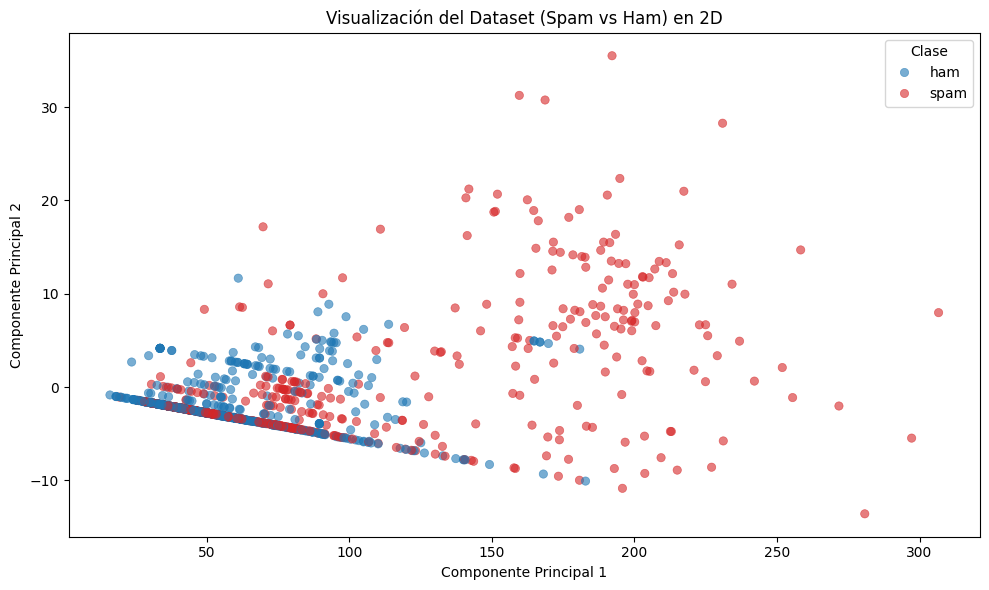


--- ANÁLISIS DEL VOCABULARIO FINAL ---
Tamaño total del vocabulario: 2623 términos.

Top 15 términos más importantes:
                Termino  Peso_TFIDF_Total
            tokennumero         76.973868
                gracias         26.067233
                   hola         23.840459
    tokennumero pequeno         22.288864
                pequeno         22.288864
                   gana         18.945069
                 gratis         16.162749
                    com         14.059532
                mensaje         13.755014
                  favor         13.698969
tokennumero tokennumero         12.883712
                 mañana         12.554033
                 código         12.460073
                     mx         11.830272
                 compra         11.179356


In [11]:
#Generacion de grafica visual de los datos
#Para visualizar cómo el modelo está separando las clases de spam y ham, se utiliza TruncatedSVD para reducir la dimensionalidad de los datos a 2 dimensiones.
print("\nGenerando visualización 2D de las clases...")
#TruncatedSVD es una técnica de reducción de dimensionalidad que es especialmente adecuada para datos dispersos como los generados por TF-IDF.
#Similar a PCA pero funciona bien con matrices dispersas, lo que lo hace ideal para nuestro caso.
reductor = TruncatedSVD(n_components=2)

#Ejecutamos la reducción de dimensionalidad sobre el conjunto de entrenamiento para obtener una representación visual de cómo el modelo está separando las clases de spam y ham en un espacio 2D.
X_2d = reductor.fit_transform(X_entrenar_final)

#Prepara el lienzo para la gráfica
plt.figure(figsize=(10, 6))
#Dibuja los puntos con Seaborn, coloreando por clase (ham o spam) para visualizar la separación entre las clases en el espacio reducido a 2 dimensiones.
sns.scatterplot(
    x=X_2d[:, 0],
    y=X_2d[:, 1],
    hue=y_entrenar,
    palette={'ham': '#1f77b4', 'spam': '#d62728'},
    alpha=0.6,
    edgecolor=None
)
#Se asigna el titulo y las etiquetas de los ejes para contextualizar la gráfica, indicando que se trata de una visualización del dataset en 2D utilizando las componentes principales obtenidas por TruncatedSVD.
plt.title('Visualización del Dataset (Spam vs Ham) en 2D')
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')
plt.legend(title='Clase')
plt.tight_layout()
plt.show()

#Análizis del vocabulario final
print("\n--- ANÁLISIS DEL VOCABULARIO FINAL ---")
#Devuelve el vocabulario final que el vectorizador TF-IDF ha construido a partir del conjunto de entrenamiento, es decir, las palabras o n-gramas que se han seleccionado como características para el modelo.
vocabulario = vectorizador.get_feature_names_out()
#Calcula la importancia total de cada término en el vocabulario sumando los pesos TF-IDF a lo largo de todas las filas (mensajes) para cada columna (término). 
# Esto nos da una medida de qué tan relevante es cada término en el conjunto de entrenamiento.
importancias_tfidf = X_entrenar_tfidf.sum(axis=0).A1
#Crea un marco de datos de pandas que contiene cada término del vocabulario junto con su peso total de TF-IDF, y luego ordena este DataFrame de mayor a menor importancia para identificar cuáles son los términos más relevantes para la clasificación.
df_vocabulario = pd.DataFrame({'Termino': vocabulario, 'Peso_TFIDF_Total': importancias_tfidf})
#Ordena el marco de datos por el peso total de TF-IDF en orden descendente para que los términos más importantes aparezcan al principio.
df_vocabulario = df_vocabulario.sort_values(by='Peso_TFIDF_Total', ascending=False)

#Obtiene el tamaño total del vocabulario, que es el número de términos únicos que el vectorizador ha seleccionado como características para el modelo. 
# Esto nos da una idea de la complejidad del modelo y la cantidad de información que está utilizando para hacer sus predicciones.
print(f"Tamaño total del vocabulario: {len(vocabulario)} términos.")
print("\nTop 15 términos más importantes:")
print(df_vocabulario.head(15).to_string(index=False))

In [12]:
#Proceso de guardado del modelo
print("\n8. Guardando modelo...")
carpeta_modelo = "Modelo_NLP"
os.makedirs(carpeta_modelo, exist_ok=True)
#Guarda los datos del vectorizador y el modelo SVM en archivos separados dentro de la carpeta "Modelo_NLP".
with open(f"{carpeta_modelo}/vectorizador.pkl", "wb") as f:
    pickle.dump(vectorizador, f)

with open(f"{carpeta_modelo}/modelo_svm.pkl", "wb") as f:
    pickle.dump(modelo_svm, f)

print("Modelo guardado correctamente.")


8. Guardando modelo...
Modelo guardado correctamente.
